<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Questao2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Questão 2: Filtro Passa-Faixas em Cascata
Nesta questão, projetaremos um filtro passa-faixas com banda entre 6000 Hz e 8000 Hz cascateando um bloco Passa-Altas ($f_{c1} = 6000$ Hz) e um bloco Passa-Baixas ($f_{c2} = 8000$ Hz).

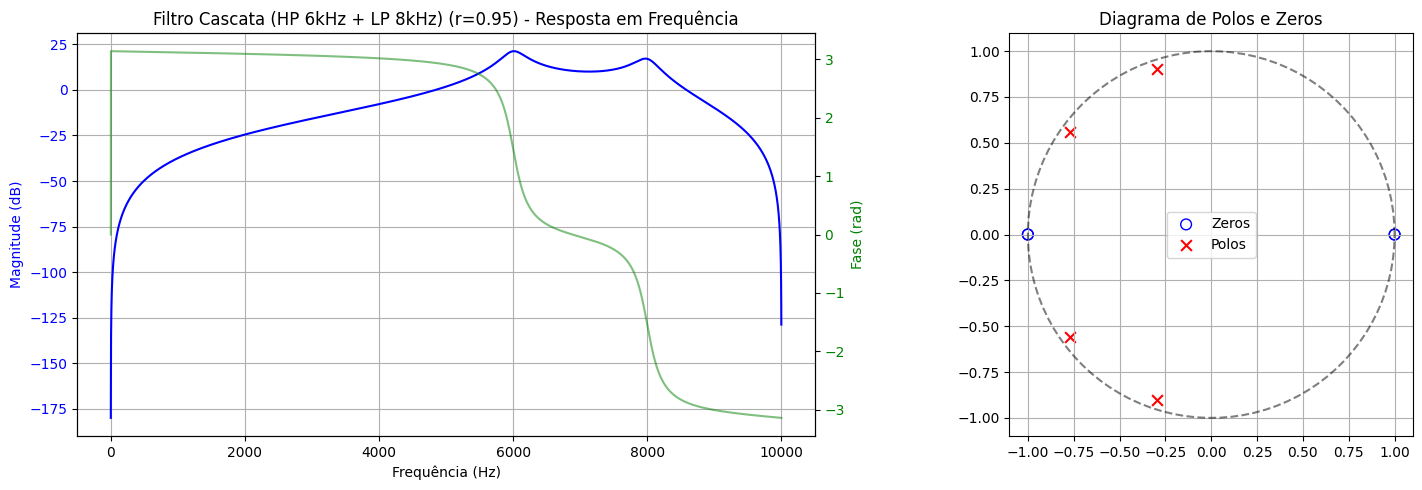

In [ ]:
fc1 = 6000 # High-pass cutoff
fc2 = 8000 # Low-pass cutoff
r = 0.95   # Chosen radius for stability and selectivity

# 1. Block HP (6000 Hz)
theta_1 = 2 * np.pi * fc1 / fs
a_hp2 = [1, -2 * r * np.cos(theta_1), r**2]
b_unit_hp = [1, -2, 1]
gain_hp = np.abs(np.polyval(a_hp2, -1) / np.polyval(b_unit_hp, -1))
b_hp2 = [x * gain_hp for x in b_unit_hp]

# 2. Block LP (8000 Hz)
theta_2 = 2 * np.pi * fc2 / fs
a_lp2 = [1, -2 * r * np.cos(theta_2), r**2]
b_unit_lp = [1, 2, 1]
gain_lp = np.sum(a_lp2) / np.sum(b_unit_lp)
b_lp2 = [x * gain_lp for x in b_unit_lp]

# Cascade (Convolution of coefficients)
b_cascade = np.convolve(b_hp2, b_lp2)
a_cascade = np.convolve(a_hp2, a_lp2)

analyze_filter(b_cascade, a_cascade, 'Filtro Cascata (HP 6kHz + LP 8kHz)', r)

### Comparação e Resultados

1.  **Largura de Banda:** O filtro da Questão 1 é um filtro de banda estreita sintonizado em uma frequência central. O filtro em cascata da Questão 2 cria uma "plataforma" entre 6000 Hz e 8000 Hz, sendo mais adequado para passar uma faixa larga de frequências.
2.  **Ordem do Sistema:** O filtro em cascata é de 4ª ordem (dois blocos de 2ª ordem), resultando em 4 polos e 4 zeros. Isso proporciona uma queda (roll-off) mais acentuada nas bandas de rejeição em comparação com o filtro de 2ª ordem simples.
3.  **Complexidade:** A cascata permite controlar as frequências de corte inferior e superior de forma independente, enquanto o filtro BP simples da questão anterior é definido principalmente pela frequência central e pelo raio $r$ (que dita a largura de banda).